In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
import plotly.express as px

sns.set(style="whitegrid")

In [20]:
df = sns.load_dataset("titanic")

In [21]:
print("First 5 rows:")
df.head()

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [22]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [23]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [24]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['deck'] = df['deck'].cat.add_categories(['Unknown'])
df['deck'] = df['deck'].fillna('Unknown')

In [25]:
df.drop(columns=['alive'], inplace=True)

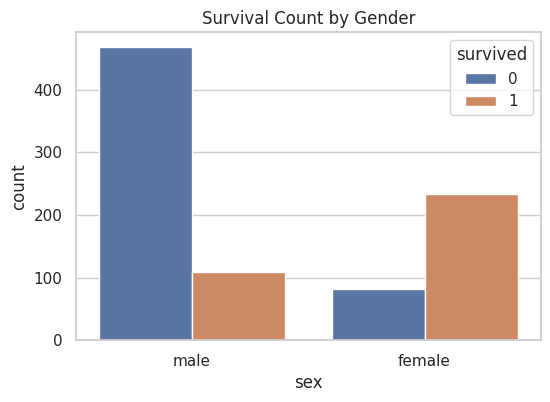

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Survival Count by Gender")
plt.show()

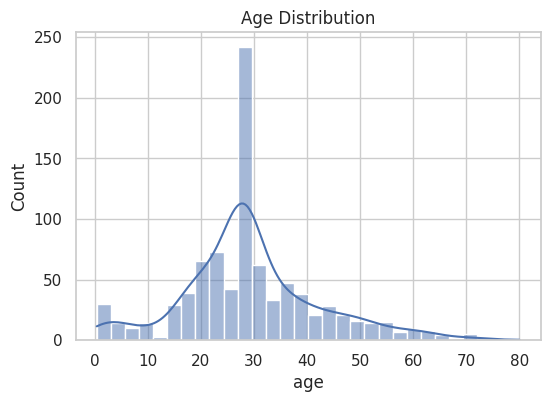

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

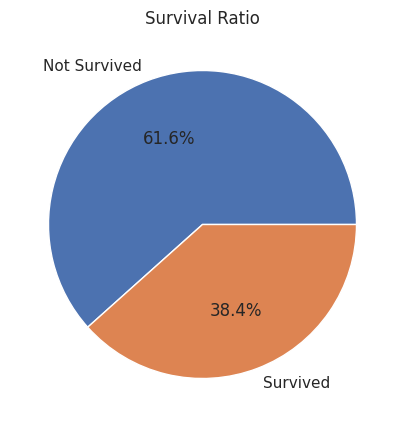

In [28]:
survival_counts = df['survived'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(survival_counts, labels=['Not Survived', 'Survived'], autopct='%1.1f%%')
plt.title("Survival Ratio")
plt.show()

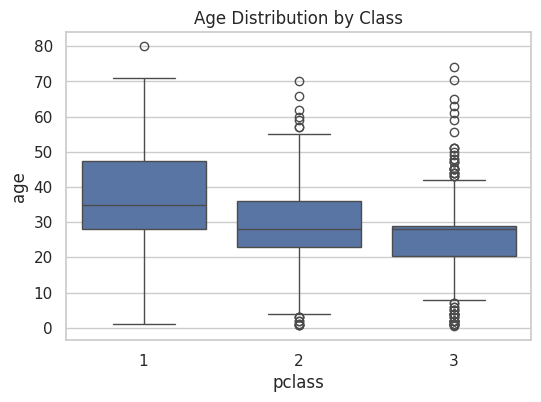

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(x='pclass', y='age', data=df)
plt.title("Age Distribution by Class")
plt.show()

In [30]:
fig = px.bar(df, x='sex', color='survived',
             title="Interactive Survival by Gender")
fig.show()

In [31]:
fig = px.histogram(df, x='age', nbins=30,
                   title="Interactive Age Distribution")
fig.show()

In [32]:
fig = px.pie(df, names='survived',
             title="Interactive Survival Pie Chart")
fig.show()

In [33]:
fig = px.box(df, x='pclass', y='age',
             title="Interactive Box Plot")
fig.show()

**Insights:**
- Females have higher survival rate than males
- 1st class passengers survived more
- Age has moderate variation but not strong survival factor
- Fare and class are correlated